## USE CASE OF PANDAS DATA ANALYISIS 

You are a data engineer at the airport of noakchott and the management would like to analyse data about flights in order to answer the folowing questions 


Data acquisition

1 - Go to https://rapidapi.com/aedbx-aedbx/api/aerodatabox/playground/apiendpoint_97755564-247f-411f-bef2-ad26a453e389 <br/>
2 - Create an account(free plan)<br/>
3- Write api call to get airpot data and save it into './data/airport.json' request from (2025-01-01 untill '2025-02-02'<br/>
4- import data  <br/>


## Data analyis <br/>


Q1. How many flights does the dataset contain in total? What is the minimum data and maximum data that we have <br/>
Q2. How many distinct airlines are represented?<br/>
Q3. Fleet mix: Which aircraft models are used most and how many times?<br/>
Q4. Busiest arrival airport: List the top‑5 arrival airports by number of scheduled arrivals.<br/>
Q5. Schedule accuracy: For flights where arrival.revisedTime is available, calculate the average arrival delay (minutes).<br/>
Q6. Route mapping: Create a mini‑table with the top‑3 most common city‑pairs (origin‑>destination IATA codes) and the associated flight counts.<br/>

# GOOD LUCK

In [ ]:
print("hello Sidi Mohamed")

In [ ]:
# import requests
# import json
# import os
# from datetime import datetime, timedelta
# import pytz
# import time

# def fetch_flights_between_dates(iata_code, start_date, end_date, output_file):
#     """
#     Récupère les données de vols pour un aéroport sur une période donnée
#     et les enregistre dans un fichier JSON.
    
#     Args:
#         iata_code (str): Code IATA de l'aéroport (ex: "NKC")
#         start_date (datetime): Date de début UTC
#         end_date (datetime): Date de fin UTC
#         output_file (str): Chemin du fichier de sortie
#     """
#     url = f"https://aerodatabox.p.rapidapi.com/flights/airports/iata/{iata_code}"

#     headers = {
#         "x-rapidapi-key": "9340651531msh24b69afeec28444p138c15jsne5d15265edcb",
#         "x-rapidapi-host": "aerodatabox.p.rapidapi.com"
#     }

#     now = datetime.utcnow().replace(tzinfo=pytz.utc)
#     interval = timedelta(minutes=720)  # Intervalle de 12 heures
#     retry_delay = 60  # Délai en secondes avant réessai après erreur 429
#     max_retries = 3  # Nombre maximum de tentatives après erreur

#     current_time = start_date
#     all_flights = []
#     quota_exceeded = False

#     # Créer le répertoire de données si inexistant
#     os.makedirs(os.path.dirname(output_file) or './data', exist_ok=True)

#     while current_time <= end_date and not quota_exceeded:
#         offset = int((current_time - now).total_seconds() / 60)
#         print(f"Fetching from {current_time.isoformat()} (offset {offset} min)")

#         querystring = {
#             "offsetMinutes": str(offset),
#             "durationMinutes": "720",
#             "withLeg": "true",
#             "direction": "Both",
#             "withCancelled": "true",
#             "withCodeshared": "true",
#             "withCargo": "true",
#             "withPrivate": "true",
#             "withLocation": "false"
#         }

#         retry_count = 0
#         success = False

#         while retry_count < max_retries and not success and not quota_exceeded:
#             try:
#                 response = requests.get(url, headers=headers, params=querystring)
                
#                 if response.status_code == 200:
#                     data = response.json()
#                     all_flights.extend(data.get("departures", []))
#                     all_flights.extend(data.get("arrivals", []))
#                     success = True
                
#                 elif response.status_code == 429:
#                     error_data = response.json()
#                     print(f"Error 429: {error_data}")
                    
#                     if retry_count < max_retries - 1:
#                         print(f"Quota atteint. Réessai dans {retry_delay} secondes... (Tentative {retry_count + 1}/{max_retries})")
#                         time.sleep(retry_delay)
#                         retry_count += 1
#                     else:
#                         print("Quota mensuel atteint - arrêt des requêtes")
#                         quota_exceeded = True
                
#                 else:
#                     print(f"Error {response.status_code}: {response.text}")
#                     break

#             except requests.exceptions.RequestException as e:
#                 print(f"Request failed: {e}")
#                 break

#         current_time += interval

#     try:
#         with open(output_file, 'w') as f:
#             json.dump(all_flights, f, indent=4)
#         print(f"Flight data saved to '{output_file}'")
#         print(f"Total flights fetched: {len(all_flights)}")
#     except Exception as e:
#         print(f"Error saving file: {e}")

In [ ]:
# start_date = datetime(2025, 1, 1, tzinfo=pytz.utc)
# end_date = datetime(2025, 2, 2, tzinfo=pytz.utc)
# fetch_flights_between_dates("NKC", start_date, end_date, './data/airport_data_filtered.json')

#===========================================================================================

In [33]:
import json
import pandas as pd

# Function to load JSON data
def load_airpot_data():
    with open('./data/airport.json', 'r') as f: 
        data = json.load(f)
    return data

# Load data
data = load_airpot_data()

# Extract all departures
all_departures = []
for entry in data:
    if "departures" in entry:
        all_departures.extend(entry["departures"])

# Create DataFrame
df = pd.DataFrame(all_departures)

df.head()

,departure,arrival,number,status,codeshareStatus,isCargo,aircraft,airline,callSign
0,"{'scheduledTime': {'utc': '2025-01-01 21:15Z',...","{'airport': {'icao': 'GOBD', 'iata': 'DSS', 'n...",HC 206,Unknown,Unknown,False,{'model': 'ATR 72'},"{'name': 'Air Senegal', 'iata': 'HC', 'icao': ...",NaN
1,"{'scheduledTime': {'utc': '2025-01-01 23:55Z',...","{'airport': {'icao': 'LFPG', 'iata': 'CDG', 'n...",AF 769,Departed,IsOperator,False,"{'reg': 'F-HUVD', 'modeS': '39D2A3', 'model': ...","{'name': 'Air France', 'iata': 'AF', 'icao': '...",AFR769
2,"{'scheduledTime': {'utc': '2025-01-02 00:40Z',...","{'airport': {'icao': 'GCLP', 'iata': 'LPA', 'n...",NT 1805,Departed,IsOperator,False,{'model': 'E295'},"{'name': 'Binter Canarias', 'iata': 'NT', 'ica...",NaN
3,"{'scheduledTime': {'utc': '2025-01-02 02:45Z',...","{'airport': {'icao': 'GMMN', 'iata': 'CMN', 'n...",AT 510,Unknown,Unknown,False,{'model': 'Boeing 737-800'},"{'name': 'Royal Air Maroc', 'iata': 'AT', 'ica...",NaN
4,"{'scheduledTime': {'utc': '2025-01-02 07:00Z',...","{'airport': {'name': 'Nema'}, 'quality': []}",L6 20,Unknown,Unknown,False,{'model': 'Boeing 737-800'},"{'name': 'Mauritania International', 'iata': ...",NaN


Q1. How many flights does the dataset contain in total? What is the minimum data and maximum data that we have

In [71]:
# For departure (keeping your working version)
departure_time = pd.to_datetime(
    df['departure'].apply(lambda x: x['scheduledTime']['utc']), 
    errors='coerce'
)
print (f"Data contains records from {departure_time.min()} to {departure_time.max()} with {len(df)} records ")

Data contains records from 2025-01-01 21:15:00+00:00 to 2025-02-19 06:50:00+00:00 with 376 records 


In [28]:
!pip install -q matplotlib


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
import matplotlib.pyplot as plt

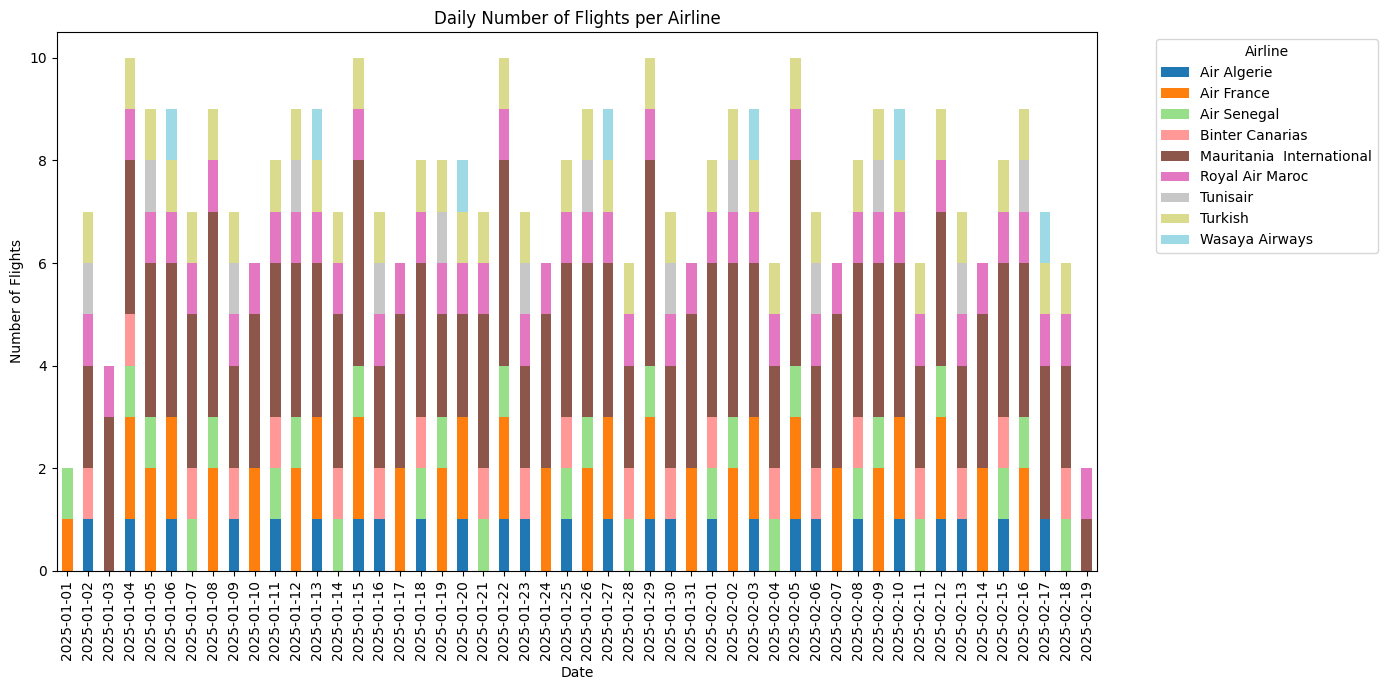

In [73]:
# Extraire l'heure de départ prévue en UTC
df['departure_time'] = df['departure'].apply(
    lambda x: x['scheduledTime']['utc'] 
    if isinstance(x, dict) and 'scheduledTime' in x and 'utc' in x['scheduledTime'] else None
)

# Convertir en datetime
df['departure_time'] = pd.to_datetime(df['departure_time'], errors='coerce')

# Extraire uniquement la date
df['date'] = df['departure_time'].dt.date

# Extraire le nom de la compagnie
df['airline_name'] = df['airline'].apply(lambda x: x['name'])

# Grouper par date et compagnie, puis tracer
daily_counts = df.groupby(['date', 'airline_name']).size().unstack(fill_value=0)
daily_counts.plot(kind='bar', stacked=True, colormap='tab20', figsize=(14, 7))

plt.title('Daily Number of Flights per Airline')
plt.xlabel('Date')
plt.ylabel('Number of Flights')
plt.legend(title='Airline', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Q2. How many distinct airlines are represented?

In [74]:
# Extract the airline name into a new column
airline_name = df['airline'].apply(lambda x: x['name'])

# Count distinct airlines
distinct_airlines = airline_name.nunique()
print(f"Distinct airlines: {distinct_airlines}")

# Group by airline name and count number of flights
flight_counts = df.groupby(airline_name).size().sort_values(ascending=True)
print(flight_counts)


Distinct airlines: 9
airline
Wasaya Airways                 7
Tunisair                      14
Binter Canarias               21
Air Algerie                   26
Air Senegal                   28
Turkish                       41
Royal Air Maroc               49
Air France                    53
Mauritania  International    137
dtype: int64


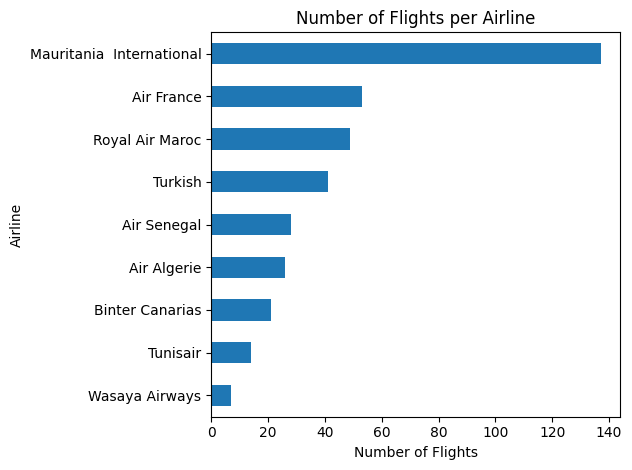

In [75]:
flight_counts.plot(kind='barh', colormap='tab20')
plt.title('Number of Flights per Airline')
plt.xlabel('Number of Flights')
plt.ylabel('Airline')
plt.tight_layout()
plt.show()

Q3. Fleet mix: Which aircraft models are used most and how many times?

In [76]:
aircraft_count = df['aircraft'].apply(
    lambda x: x['model'] if isinstance(x, dict) and 'model' in x else None
)

aircraft_counts = df.groupby(aircraft_count).size().sort_values(ascending=True)
print(aircraft_counts)

aircraft
Airbus A330         1
Airbus A330-200     6
Boeing 737-600      8
Airbus A330-300    13
Airbus A320        14
Embraer RJ145      19
E295               21
ATR 72             28
Embraer 175        39
Boeing 737-700     43
Airbus A350-900    53
Boeing 737         56
Boeing 737-800     68
dtype: int64


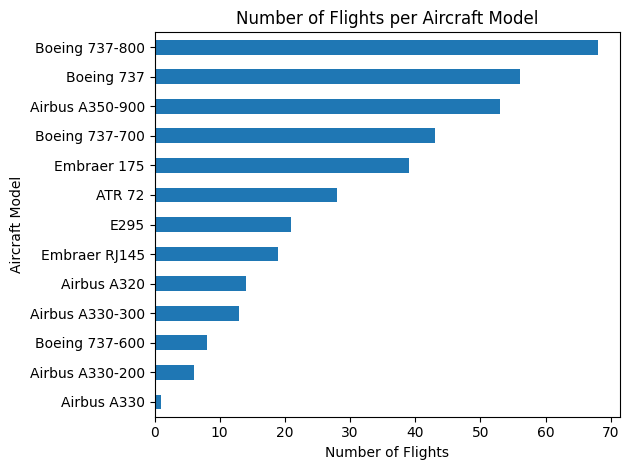

In [77]:
aircraft_counts.plot(kind='barh', colormap='tab20')
plt.title('Number of Flights per Aircraft Model')
plt.xlabel('Number of Flights')
plt.ylabel('Aircraft Model')
plt.tight_layout()
plt.show()

Q4. Busiest arrival airport: List the top‑5 arrival airports by number of scheduled arrivals.

In [78]:
number_top = 5

top_arrivals = df['arrival'].apply(
    lambda x: x['airport']['name'] if isinstance(x, dict) else None
).value_counts().head(number_top)

print(f"Top {number_top} arrival airports:")
for airport, count in top_arrivals.items():
    print(f"{airport}: {count} flights")

Top 5 arrival airports:
Casablanca: 90 flights
Dakar: 64 flights
Istanbul: 34 flights
Gran Canaria Island: 34 flights
Tunis: 31 flights


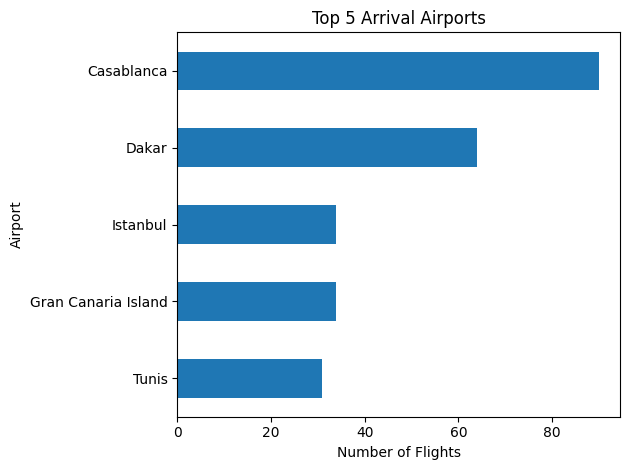

In [79]:
top_arrivals.plot(kind='barh', colormap='tab20',)
plt.title(f'Top {number_top} Arrival Airports')
plt.xlabel('Number of Flights')
plt.ylabel('Airport')
plt.gca().invert_yaxis()  # Inverse l'ordre pour avoir le plus grand en haut
plt.tight_layout()
plt.show()

Q5. Schedule accuracy: For flights where arrival.revisedTime is available, calculate the average arrival delay (minutes).

In [80]:
# Étape 1 : Extraire les temps d’arrivée prévu et révisé
df['arrival_scheduled'] = df['arrival'].apply(
    lambda x: x['scheduledTime']['utc'] if isinstance(x, dict) and 'scheduledTime' in x and 'utc' in x['scheduledTime'] else None
)

df['arrival_revised'] = df['arrival'].apply(
    lambda x: x['revisedTime']['utc'] if isinstance(x, dict) and 'revisedTime' in x and 'utc' in x['revisedTime'] else None
)

# Étape 2 : Convertir en datetime
df['arrival_scheduled'] = pd.to_datetime(df['arrival_scheduled'], errors='coerce')
df['arrival_revised'] = pd.to_datetime(df['arrival_revised'], errors='coerce')

# Étape 3 : Garder uniquement les lignes avec temps révisé dispo
df_filtered = df[df['arrival_revised'].notna() & df['arrival_scheduled'].notna()].copy()

# Étape 4 : Calculer le retard en minutes
df_filtered['arrival_delay_min'] = (df_filtered['arrival_revised'] - df_filtered['arrival_scheduled']).dt.total_seconds() / 60

# Étape 5 : Moyenne du retard par compagnie
average_delay_by_airline = df_filtered.groupby('airline_name')['arrival_delay_min'].mean().sort_values(ascending=False)

print(average_delay_by_airline)


airline_name
Mauritania  International    46.384615
Binter Canarias              31.761905
Air France                  -21.733333
Turkish                     -29.642857
Name: arrival_delay_min, dtype: float64


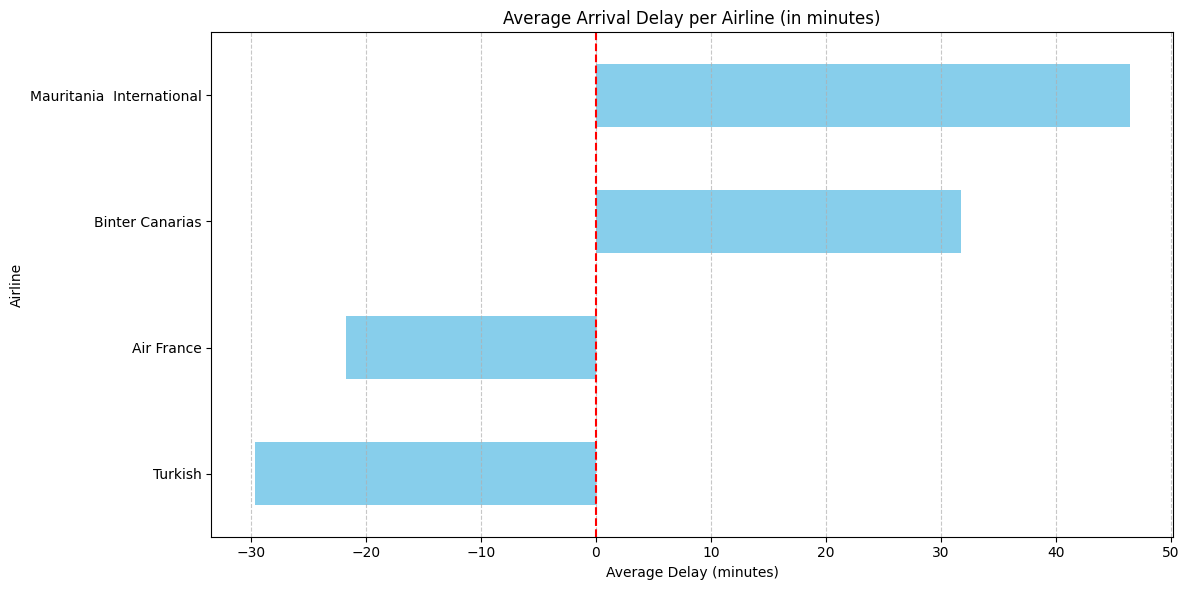

In [81]:
plt.figure(figsize=(12, 6))
average_delay_by_airline.sort_values().plot(kind='barh', color='skyblue')

plt.axvline(0, color='red', linestyle='--')  # Add a red line at 0 delay
plt.title('Average Arrival Delay per Airline (in minutes)')
plt.xlabel('Average Delay (minutes)')
plt.ylabel('Airline')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Q6. Route mapping: Create a mini‑table with the top‑3 most common city‑pairs (origin‑>destination IATA codes) and the associated flight counts.

In [70]:
# Extract origin and destination IATA codes safely
origin = df['departure'].apply(
    lambda x: x.get('airport', {}).get('name', 'NKC') if isinstance(x, dict) else None
)

destination= df['arrival'].apply(
    lambda x: x.get('airport', {}).get('iata') if isinstance(x, dict) else None
)

# Create route column by combining origin and destination
routes = origin + '→' + destination

# Count occurrences of each route and get top 3
top_routes = routes.value_counts().head(3)

# Convert to mini-table format
route_table = top_routes.reset_index()
route_table.columns = ['Route (Origin→Destination)', 'Flight Count']

print("Top 3 Most Common Flight Routes:")
print(route_table.to_string(index=False))

Top 3 Most Common Flight Routes:
Route (Origin→Destination)  Flight Count
                   NKC→CMN            89
                   NKC→DSS            64
                   NKC→LPA            34


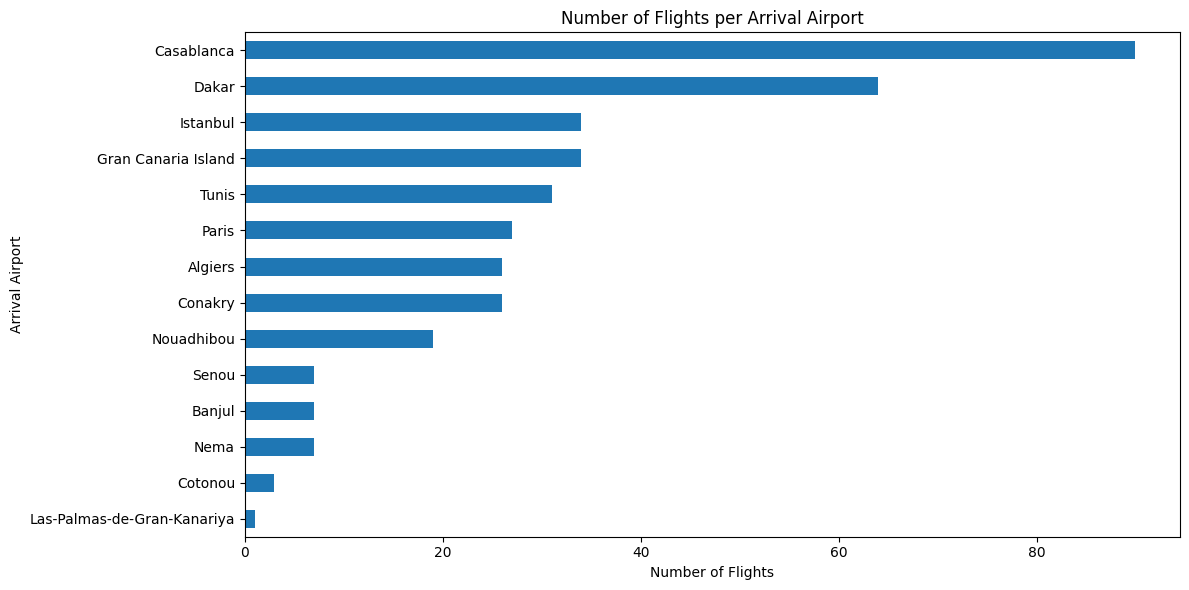

In [69]:
arrival_airport_name = df['arrival'].apply(
    lambda x: x['airport']['name'] if isinstance(x, dict) and 'airport' in x else None
)

flight_counts  = df.groupby([arrival_airport_name]).size().sort_values(ascending=True)

plt.figure(figsize=(12, 6))
flight_counts.plot(kind='barh')
plt.title('Number of Flights per Arrival Airport')
plt.xlabel('Number of Flights')
plt.ylabel('Arrival Airport')
plt.tight_layout()
plt.show()